# Label Distribution + Metadata Table (`inputs/train.csv`)

This notebook does two things:
1. Build a **meta info table** by joining `train.csv` with scan PNG file metadata.
2. Analyze **label distribution** (positives, areas, long-tail) from RLE masks.


In [1]:
from __future__ import annotations

import json
import math
import os
import re
import sys
from pathlib import Path
from typing import Any

import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    for p in (start, *start.parents):
        if (p / "inputs" / "train.csv").exists():
            return p
        if (p / ".git").exists() and (p / "README.md").exists():
            return p
    raise RuntimeError(
        "Cannot find repo root. Start Jupyter from the project directory, or ensure inputs/train.csv exists."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("repo_root:", REPO_ROOT)

DATA_CSV = Path("inputs/train.csv")
TRAIN_DIR = Path("inputs/train")
OUT_DIR = Path("outputs/analysis")
OUT_BY_CLASS_CSV = OUT_DIR / "label_distribution_by_class.csv"
OUT_SUMMARY_JSON = OUT_DIR / "label_distribution_summary.json"
OUT_META_TABLE_CSV = OUT_DIR / "meta_info_table.csv"

assert DATA_CSV.exists(), f"Not found: {DATA_CSV.resolve()}"
assert TRAIN_DIR.exists(), f"Not found: {TRAIN_DIR.resolve()}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_TAG = '00_label_analysis'
OUT_NB_DIR = OUT_DIR / NOTEBOOK_TAG
OUT_NB_DIR.mkdir(parents=True, exist_ok=True)

print("csv:", DATA_CSV)
print("train_dir:", TRAIN_DIR)
print('out:', OUT_DIR)
print('out_nb:', OUT_NB_DIR)


repo_root: /home/ubuntu/UW-Madison_GI_Tract_Image_Segmentation
csv: inputs/train.csv
train_dir: inputs/train
out: outputs/analysis
out_nb: outputs/analysis/00_label_analysis


In [2]:
df = pd.read_csv(DATA_CSV)
df.head()

,id,class,segmentation
0,case123_day20_slice_0001,large_bowel,NaN
1,case123_day20_slice_0001,small_bowel,NaN
2,case123_day20_slice_0001,stomach,NaN
3,case123_day20_slice_0002,large_bowel,NaN
4,case123_day20_slice_0002,small_bowel,NaN


In [3]:
required = {"id", "class", "segmentation"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing columns: {sorted(missing)}")

print("rows:", len(df))
print("unique slices (id):", df["id"].nunique())
print("classes:", sorted(df["class"].unique().tolist()))


rows: 115488
unique slices (id): 38496
classes: ['large_bowel', 'small_bowel', 'stomach']


## Build meta info table

Goal: create a table that contains:
- `case`, `case_day`, `id`, `slice_idx`
- `H`, `W`
- `pixel_spacing_x`, `pixel_spacing_y` (parsed from PNG filename)
- `class`, `segmentation`
- `png_path`

Notes:
- `train.csv` has **3 rows per slice** (one per class), so the meta table is also **row-per-(slice,class)**.
- Scan filenames are expected to look like: `slice_0060_266_266_1.50_1.50.png`.


In [4]:
_ID_RE = re.compile(r"^(case\d+)_day(\d+)_slice_(\d+)$")
_SCAN_RE = re.compile(r"^slice_(\d+)_(\d+)_(\d+)_([0-9.]+)_([0-9.]+)\.png$")


def parse_id(_id: str) -> dict[str, object]:
    m = _ID_RE.match(str(_id))
    if not m:
        raise ValueError(f"Unexpected id format: {_id!r}")
    case = m.group(1)
    day = int(m.group(2))
    slice_idx = int(m.group(3))
    case_day = f"{case}_day{day}"
    return {"case": case, "day": day, "case_day": case_day, "slice_idx": slice_idx}


def parse_scan_filename(name: str) -> dict[str, object]:
    m = _SCAN_RE.match(str(name))
    if not m:
        raise ValueError(f"Unexpected scan filename: {name!r}")
    return {
        "slice_idx": int(m.group(1)),
        "H": int(m.group(2)),
        "W": int(m.group(3)),
        "pixel_spacing_x": float(m.group(4)),
        "pixel_spacing_y": float(m.group(5)),
    }


def iter_scan_pngs(train_dir: Path):
    # Expected layout: inputs/train/case*/case*_day*/scans/*.png
    for p in train_dir.glob("case*/case*_day*/scans/*.png"):
        yield p


scan_rows = []
for p in sorted(iter_scan_pngs(TRAIN_DIR)):
    # .../inputs/train/case108/case108_day10/scans/slice_0060_266_266_1.50_1.50.png
    case = p.parents[2].name  # case108
    case_day = p.parents[1].name  # case108_day10
    scan_meta = parse_scan_filename(p.name)
    scan_rows.append(
        {
            "case": case,
            "case_day": case_day,
            **scan_meta,
            "png_path": str(p),
        }
    )

scan_df = pd.DataFrame.from_records(scan_rows)
print("scan pngs:", len(scan_df))
scan_df.head()

scan pngs: 38496


,case,case_day,slice_idx,H,W,pixel_spacing_x,pixel_spacing_y,png_path
0,case101,case101_day20,1,266,266,1.5,1.5,inputs/train/case101/case101_day20/scans/slice...
1,case101,case101_day20,2,266,266,1.5,1.5,inputs/train/case101/case101_day20/scans/slice...
2,case101,case101_day20,3,266,266,1.5,1.5,inputs/train/case101/case101_day20/scans/slice...
3,case101,case101_day20,4,266,266,1.5,1.5,inputs/train/case101/case101_day20/scans/slice...
4,case101,case101_day20,5,266,266,1.5,1.5,inputs/train/case101/case101_day20/scans/slice...


In [5]:
df_meta = df.copy()
parsed = df_meta["id"].map(parse_id)
df_meta = pd.concat([df_meta, pd.DataFrame.from_records(parsed)], axis=1)

# Join with scan metadata (H/W/spacing/png_path) on (case_day, slice_idx)
df_meta = df_meta.merge(
    scan_df,
    on=["case", "case_day", "slice_idx"],
    how="left",
    validate="m:1",
)

missing_png = int(df_meta["png_path"].isna().sum())
print("rows:", len(df_meta))
print("missing png_path:", missing_png)

df_meta.head()

rows: 115488
missing png_path: 0


,id,class,segmentation,case,day,case_day,slice_idx,H,W,pixel_spacing_x,pixel_spacing_y,png_path
0,case123_day20_slice_0001,large_bowel,NaN,case123,20,case123_day20,1,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...
1,case123_day20_slice_0001,small_bowel,NaN,case123,20,case123_day20,1,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...
2,case123_day20_slice_0001,stomach,NaN,case123,20,case123_day20,1,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...
3,case123_day20_slice_0002,large_bowel,NaN,case123,20,case123_day20,2,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...
4,case123_day20_slice_0002,small_bowel,NaN,case123,20,case123_day20,2,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...


In [6]:
def rle_area(rle: Any) -> int:
    if rle is None:
        return 0
    if isinstance(rle, float) and math.isnan(rle):
        return 0
    s = str(rle).strip()
    if not s:
        return 0
    parts = s.split()
    if len(parts) < 2:
        return 0
    return sum(int(x) for x in parts[1::2])

# Add label-related fields
# - label_positive: whether the mask is non-empty
# - label_area: foreground pixel count from RLE
# - label_frac: label_area / (H*W)
df_meta["label_area"] = df_meta["segmentation"].map(rle_area).astype("int64")
df_meta["label_positive"] = df_meta["label_area"] > 0
df_meta["label_frac"] = df_meta["label_area"] / (df_meta["H"].astype("float64") * df_meta["W"].astype("float64"))

# Write meta info table
df_meta.to_csv(OUT_META_TABLE_CSV, index=False)
print("wrote:", OUT_META_TABLE_CSV)

df_meta.head(10)

wrote: outputs/analysis/meta_info_table.csv


,id,class,segmentation,case,day,case_day,slice_idx,H,W,pixel_spacing_x,pixel_spacing_y,png_path,label_area,label_positive,label_frac
0,case123_day20_slice_0001,large_bowel,NaN,case123,20,case123_day20,1,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
1,case123_day20_slice_0001,small_bowel,NaN,case123,20,case123_day20,1,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
2,case123_day20_slice_0001,stomach,NaN,case123,20,case123_day20,1,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
3,case123_day20_slice_0002,large_bowel,NaN,case123,20,case123_day20,2,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
4,case123_day20_slice_0002,small_bowel,NaN,case123,20,case123_day20,2,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
5,case123_day20_slice_0002,stomach,NaN,case123,20,case123_day20,2,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
6,case123_day20_slice_0003,large_bowel,NaN,case123,20,case123_day20,3,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
7,case123_day20_slice_0003,small_bowel,NaN,case123,20,case123_day20,3,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
8,case123_day20_slice_0003,stomach,NaN,case123,20,case123_day20,3,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0
9,case123_day20_slice_0004,large_bowel,NaN,case123,20,case123_day20,4,266,266,1.5,1.5,inputs/train/case123/case123_day20/scans/slice...,0,False,0.0


## Scan geometry distributions (H/W, pixel spacing)

Use `scan_df` (one row per scan PNG) so H/W and spacing are not triple-counted across the 3 classes in `df_meta`.


unique scans: 38496
unique (H,W): 4
unique (pixel_spacing_x, pixel_spacing_y): 2
wrote: outputs/analysis/00_label_analysis/scan_hw_counts.csv
wrote: outputs/analysis/00_label_analysis/scan_pixel_spacing_counts.csv
wrote: outputs/analysis/00_label_analysis/scan_geometry_distributions.png


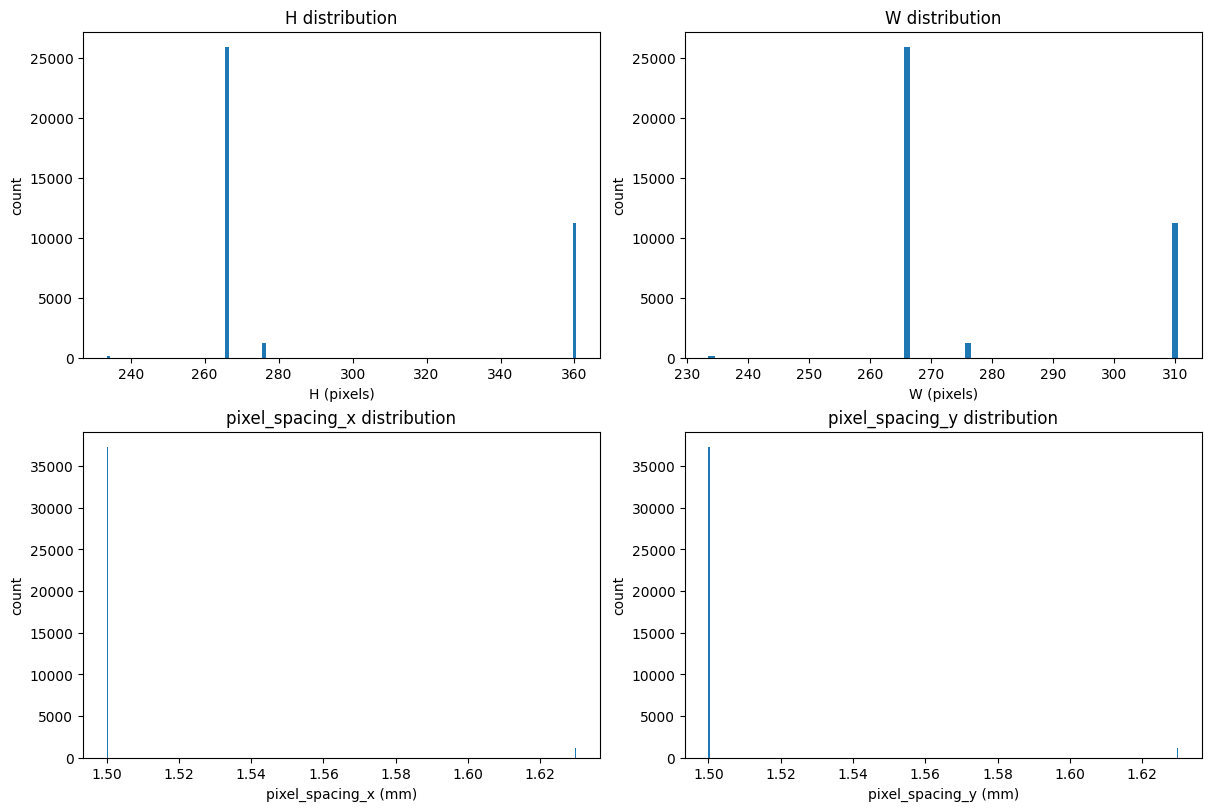

wrote: outputs/analysis/00_label_analysis/scan_hw_top_sizes.png


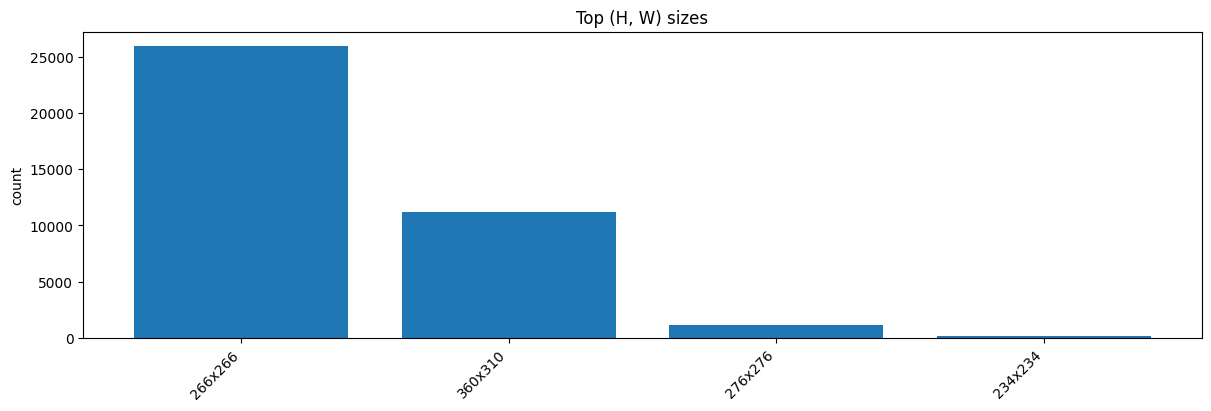

wrote: outputs/analysis/00_label_analysis/scan_pixel_spacing_top_pairs.png


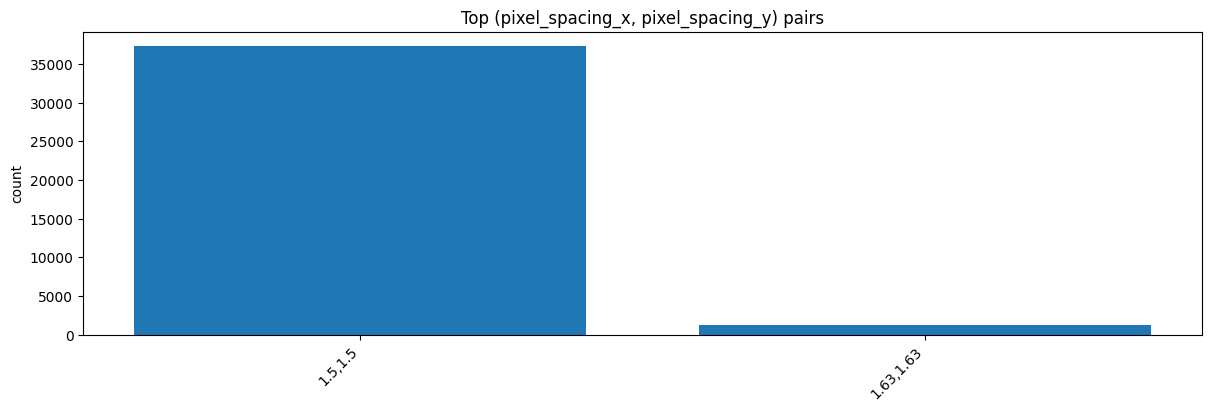

In [7]:
# ---- Scan geometry distributions (unique scans) ----
# Note: df_meta has 3 rows per slice (one per class), so use scan_df to avoid triple-counting.

import numpy as np

OUT_NB_DIR.mkdir(parents=True, exist_ok=True)

geom = scan_df.dropna(subset=["H", "W", "pixel_spacing_x", "pixel_spacing_y"]).copy()
print("unique scans:", len(geom))
print("unique (H,W):", geom[["H", "W"]].drop_duplicates().shape[0])
print(
    "unique (pixel_spacing_x, pixel_spacing_y):",
    geom[["pixel_spacing_x", "pixel_spacing_y"]].drop_duplicates().shape[0],
)

# (H, W) pair counts
hw_counts = (
    geom.groupby(["H", "W"]).size().sort_values(ascending=False).rename("count").reset_index()
)
HW_COUNTS_CSV = OUT_NB_DIR / "scan_hw_counts.csv"
hw_counts.to_csv(HW_COUNTS_CSV, index=False)
print("wrote:", HW_COUNTS_CSV)
hw_counts.head(20)

# Pixel spacing pair counts
sp_counts = (
    geom.groupby(["pixel_spacing_x", "pixel_spacing_y"])
    .size()
    .sort_values(ascending=False)
    .rename("count")
    .reset_index()
)
SP_COUNTS_CSV = OUT_NB_DIR / "scan_pixel_spacing_counts.csv"
sp_counts.to_csv(SP_COUNTS_CSV, index=False)
print("wrote:", SP_COUNTS_CSV)
sp_counts.head(20)

# Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

h = geom["H"].to_numpy(dtype=int)
w = geom["W"].to_numpy(dtype=int)
h_bins = np.arange(h.min(), h.max() + 2) - 0.5
w_bins = np.arange(w.min(), w.max() + 2) - 0.5

axes[0, 0].hist(h, bins=h_bins)
axes[0, 0].set_title("H distribution")
axes[0, 0].set_xlabel("H (pixels)")
axes[0, 0].set_ylabel("count")

axes[0, 1].hist(w, bins=w_bins)
axes[0, 1].set_title("W distribution")
axes[0, 1].set_xlabel("W (pixels)")
axes[0, 1].set_ylabel("count")

axes[1, 0].hist(geom["pixel_spacing_x"].to_numpy(dtype=float), bins="auto")
axes[1, 0].set_title("pixel_spacing_x distribution")
axes[1, 0].set_xlabel("pixel_spacing_x (mm)")
axes[1, 0].set_ylabel("count")

axes[1, 1].hist(geom["pixel_spacing_y"].to_numpy(dtype=float), bins="auto")
axes[1, 1].set_title("pixel_spacing_y distribution")
axes[1, 1].set_xlabel("pixel_spacing_y (mm)")
axes[1, 1].set_ylabel("count")

GEOM_PNG = OUT_NB_DIR / "scan_geometry_distributions.png"
fig.savefig(GEOM_PNG, dpi=200)
print("wrote:", GEOM_PNG)
plt.show()

# Top (H,W) sizes
top_hw = hw_counts.head(20)
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
labels = [f"{int(h)}x{int(w)}" for h, w in zip(top_hw["H"], top_hw["W"])]
ax.bar(range(len(top_hw)), top_hw["count"].to_numpy())
ax.set_xticks(range(len(top_hw)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("count")
ax.set_title("Top (H, W) sizes")

HW_TOP_PNG = OUT_NB_DIR / "scan_hw_top_sizes.png"
fig.savefig(HW_TOP_PNG, dpi=200)
print("wrote:", HW_TOP_PNG)
plt.show()

# Top pixel spacing pairs
top_sp = sp_counts.head(20)
fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
labels = [f"{x:g},{y:g}" for x, y in zip(top_sp["pixel_spacing_x"], top_sp["pixel_spacing_y"])]
ax.bar(range(len(top_sp)), top_sp["count"].to_numpy())
ax.set_xticks(range(len(top_sp)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("count")
ax.set_title("Top (pixel_spacing_x, pixel_spacing_y) pairs")

SP_TOP_PNG = OUT_NB_DIR / "scan_pixel_spacing_top_pairs.png"
fig.savefig(SP_TOP_PNG, dpi=200)
print("wrote:", SP_TOP_PNG)
plt.show()


## Label imbalance quantification

We quantify imbalance at two levels:
- **Row-level (per class row)**: since `train.csv` has one row per `(id, class)`.
- **Slice-level (any class)**: aggregate over the 3 classes per slice.

Key metrics:
- `positive_rate`: fraction of rows/slices with any mask.
- `pos_pixel_ratio`: total foreground pixels / total pixels.
- `label_frac` distribution: long-tail via quantiles.


In [8]:
import json
import numpy as np

# ---- Row-level (per class row) ----
rows_total = len(df_meta)
rows_pos = int(df_meta['label_positive'].sum())
rows_pos_rate = rows_pos / rows_total

row_pos_pixel_ratio = df_meta['label_area'].sum() / (df_meta['H'] * df_meta['W']).sum()

print('Row-level (per class rows)')
print('  rows_total:', rows_total)
print('  rows_positive:', rows_pos)
print('  positive_rate:', rows_pos_rate)
print('  pos_pixel_ratio:', float(row_pos_pixel_ratio))

by_class = (
    df_meta
    .groupby('class', dropna=False)
    .agg(
        rows=('id', 'size'),
        positive=('label_positive', 'sum'),
        positive_rate=('label_positive', 'mean'),
        sum_area=('label_area', 'sum'),
        mean_area=('label_area', 'mean'),
        median_area=('label_area', 'median'),
        mean_frac=('label_frac', 'mean'),
        median_frac=('label_frac', 'median'),
    )
    .sort_values(['positive_rate', 'sum_area'], ascending=False)
)

# Median over *all* rows will be 0 because most rows are negative (area=0).
# For a more informative summary, also compute stats on positive rows only.
by_class_pos = (
    df_meta.loc[df_meta['label_positive']]
    .groupby('class', dropna=False)
    .agg(
        positive_mean_area=('label_area', 'mean'),
        positive_median_area=('label_area', 'median'),
        positive_mean_frac=('label_frac', 'mean'),
        positive_median_frac=('label_frac', 'median'),
    )
)
by_class = by_class.join(by_class_pos, how='left')
by_class['pos_pixel_ratio'] = by_class['sum_area'] / df_meta.assign(_pixels=df_meta['H'] * df_meta['W']).groupby('class')['_pixels'].sum()

# Persist
OUT_NB_DIR.mkdir(parents=True, exist_ok=True)
BY_CLASS_CSV = OUT_NB_DIR / 'label_imbalance_by_class.csv'
by_class.to_csv(BY_CLASS_CSV)
print('wrote:', BY_CLASS_CSV)

row_summary = {
    'rows_total': int(rows_total),
    'rows_positive': int(rows_pos),
    'positive_rate': float(rows_pos_rate),
    'pos_pixel_ratio': float(row_pos_pixel_ratio),
}
ROW_SUMMARY_JSON = OUT_NB_DIR / 'label_imbalance_row_level_summary.json'
ROW_SUMMARY_JSON.write_text(json.dumps(row_summary, indent=2))
print('wrote:', ROW_SUMMARY_JSON)

by_class


Row-level (per class rows)
  rows_total: 115488
  rows_positive: 33913
  positive_rate: 0.2936495566638958
  pos_pixel_ratio: 0.005557955112470781
wrote: outputs/analysis/00_label_analysis/label_imbalance_by_class.csv
wrote: outputs/analysis/00_label_analysis/label_imbalance_row_level_summary.json


,rows,positive,positive_rate,sum_area,mean_area,median_area,mean_frac,median_frac,positive_mean_area,positive_median_area,positive_mean_frac,positive_median_frac,pos_pixel_ratio
class,,,,,,,,,,,,,
large_bowel,38496,14085,0.365882,21933578,569.762521,0.0,0.007031,0.0,1557.229535,1312.0,0.019217,0.015928,0.006883
small_bowel,38496,11201,0.290965,20080562,521.627234,0.0,0.006467,0.0,1792.747255,1600.0,0.022225,0.020111,0.006301
stomach,38496,8627,0.224101,11121847,288.909159,0.0,0.003631,0.0,1289.190565,962.0,0.016204,0.012070,0.003490


In [9]:
# Foreground fraction long-tail (row-level)
q = [0.5, 0.9, 0.95, 0.99, 0.999]
print('label_frac quantiles (all rows):')
print(df_meta['label_frac'].quantile(q))

print('\nlabel_frac quantiles (positive rows only):')
pos = df_meta.loc[df_meta['label_positive'], 'label_frac']
print(pos.quantile(q))

OUT_NB_DIR.mkdir(parents=True, exist_ok=True)
ROW_QUANT_ALL_CSV = OUT_NB_DIR / 'label_frac_quantiles_all_rows.csv'
ROW_QUANT_POS_CSV = OUT_NB_DIR / 'label_frac_quantiles_positive_rows.csv'
df_meta['label_frac'].quantile(q).to_csv(ROW_QUANT_ALL_CSV, header=['label_frac'])
pos.quantile(q).to_csv(ROW_QUANT_POS_CSV, header=['label_frac'])
print('wrote:', ROW_QUANT_ALL_CSV)
print('wrote:', ROW_QUANT_POS_CSV)


label_frac quantiles (all rows):
0.500    0.000000
0.900    0.022565
0.950    0.031842
0.990    0.050655
0.999    0.074927
Name: label_frac, dtype: float64

label_frac quantiles (positive rows only):
0.500    0.016254
0.900    0.038569
0.950    0.046590
0.990    0.064489
0.999    0.086431
Name: label_frac, dtype: float64
wrote: outputs/analysis/00_label_analysis/label_frac_quantiles_all_rows.csv
wrote: outputs/analysis/00_label_analysis/label_frac_quantiles_positive_rows.csv


wrote: outputs/analysis/00_label_analysis/label_frac_hist_row_level.png


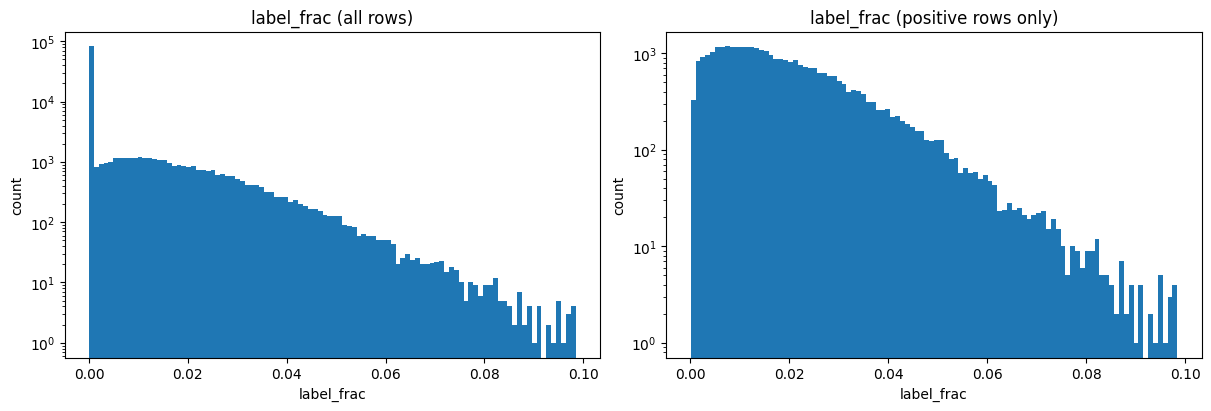

/tmp/ipykernel_15214/529302030.py:36: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=classes, showfliers=False)


wrote: outputs/analysis/00_label_analysis/label_frac_boxplot_by_class_positive_row_level.png


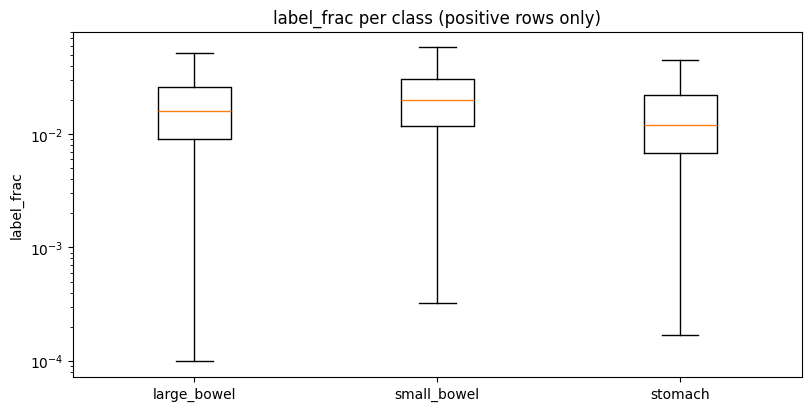

In [10]:
# Plot label_frac distribution (row-level)
# Tips:
# - all rows includes many zeros; use a separate plot for positive-only to see shape.
# - using log scale on y helps show long-tail.

import numpy as np

OUT_NB_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

all_frac = df_meta['label_frac'].fillna(0.0).to_numpy(dtype=float)
pos_frac = df_meta.loc[df_meta['label_positive'], 'label_frac'].to_numpy(dtype=float)

axes[0].hist(all_frac, bins=100)
axes[0].set_title('label_frac (all rows)')
axes[0].set_xlabel('label_frac')
axes[0].set_ylabel('count')
axes[0].set_yscale('log')

axes[1].hist(pos_frac, bins=100)
axes[1].set_title('label_frac (positive rows only)')
axes[1].set_xlabel('label_frac')
axes[1].set_ylabel('count')
axes[1].set_yscale('log')

ROW_HIST_PNG = OUT_NB_DIR / 'label_frac_hist_row_level.png'
fig.savefig(ROW_HIST_PNG, dpi=200)
print('wrote:', ROW_HIST_PNG)
plt.show()

# Per-class positive-only distributions (boxplot)
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
classes = list(by_class.index)
data = [df_meta.loc[(df_meta['class'] == c) & (df_meta['label_positive']), 'label_frac'].to_numpy(dtype=float) for c in classes]
ax.boxplot(data, labels=classes, showfliers=False)
ax.set_title('label_frac per class (positive rows only)')
ax.set_ylabel('label_frac')
ax.set_yscale('log')

ROW_BOX_PNG = OUT_NB_DIR / 'label_frac_boxplot_by_class_positive_row_level.png'
fig.savefig(ROW_BOX_PNG, dpi=200)
print('wrote:', ROW_BOX_PNG)
plt.show()


In [11]:
import json

# ---- Slice-level (aggregate over 3 classes per id) ----
# Each slice id appears 3 times (one per class). Aggregate to answer: "is this slice positive for any class?"
per_slice = (
    df_meta
    .groupby(['id', 'case', 'case_day', 'slice_idx', 'H', 'W'], as_index=False)
    .agg(
        any_positive=('label_positive', 'any'),
        total_area=('label_area', 'sum'),
    )
)
per_slice['total_frac'] = per_slice['total_area'] / (per_slice['H'].astype('float64') * per_slice['W'].astype('float64'))

slices_total = len(per_slice)
slices_pos = int(per_slice['any_positive'].sum())
slice_pos_rate = slices_pos / slices_total
slice_pos_pixel_ratio = per_slice['total_area'].sum() / (per_slice['H'] * per_slice['W']).sum()

print('Slice-level (any class)')
print('  slices_total:', slices_total)
print('  slices_positive:', slices_pos)
print('  positive_rate:', slice_pos_rate)
print('  pos_pixel_ratio:', float(slice_pos_pixel_ratio))

slice_q = [0.5, 0.9, 0.95, 0.99, 0.999]
slice_quant = per_slice.loc[per_slice['any_positive'], 'total_frac'].quantile(slice_q)
print('\ntotal_frac quantiles (positive slices only):')
print(slice_quant)

slice_quant_all = per_slice['total_frac'].quantile(slice_q)
print('\ntotal_frac quantiles (all slices):')
print(slice_quant_all)

# Persist
OUT_NB_DIR.mkdir(parents=True, exist_ok=True)
PER_SLICE_CSV = OUT_NB_DIR / 'label_imbalance_per_slice.csv'
per_slice.to_csv(PER_SLICE_CSV, index=False)
print('wrote:', PER_SLICE_CSV)

slice_summary = {
    'slices_total': int(slices_total),
    'slices_positive': int(slices_pos),
    'positive_rate': float(slice_pos_rate),
    'pos_pixel_ratio': float(slice_pos_pixel_ratio),
}
SLICE_SUMMARY_JSON = OUT_NB_DIR / 'label_imbalance_slice_level_summary.json'
SLICE_SUMMARY_JSON.write_text(json.dumps(slice_summary, indent=2))
print('wrote:', SLICE_SUMMARY_JSON)

SLICE_QUANT_CSV = OUT_NB_DIR / 'total_frac_quantiles_positive_slices.csv'
slice_quant.to_csv(SLICE_QUANT_CSV, header=['total_frac'])
print('wrote:', SLICE_QUANT_CSV)

SLICE_QUANT_ALL_CSV = OUT_NB_DIR / 'total_frac_quantiles_all_slices.csv'
slice_quant_all.to_csv(SLICE_QUANT_ALL_CSV, header=['total_frac'])
print('wrote:', SLICE_QUANT_ALL_CSV)

per_slice.head()


Slice-level (any class)
  slices_total: 38496
  slices_positive: 16590
  positive_rate: 0.43095386533665836
  pos_pixel_ratio: 0.01667386533741234

total_frac quantiles (positive slices only):
0.500    0.037933
0.900    0.067924
0.950    0.079535
0.990    0.096394
0.999    0.115417
Name: total_frac, dtype: float64

total_frac quantiles (all slices):
0.500    0.000000
0.900    0.054325
0.950    0.065493
0.990    0.088952
0.999    0.107946
Name: total_frac, dtype: float64
wrote: outputs/analysis/00_label_analysis/label_imbalance_per_slice.csv
wrote: outputs/analysis/00_label_analysis/label_imbalance_slice_level_summary.json
wrote: outputs/analysis/00_label_analysis/total_frac_quantiles_positive_slices.csv
wrote: outputs/analysis/00_label_analysis/total_frac_quantiles_all_slices.csv


,id,case,case_day,slice_idx,H,W,any_positive,total_area,total_frac
0,case101_day20_slice_0001,case101,case101_day20,1,266,266,False,0,0.0
1,case101_day20_slice_0002,case101,case101_day20,2,266,266,False,0,0.0
2,case101_day20_slice_0003,case101,case101_day20,3,266,266,False,0,0.0
3,case101_day20_slice_0004,case101,case101_day20,4,266,266,False,0,0.0
4,case101_day20_slice_0005,case101,case101_day20,5,266,266,False,0,0.0


wrote: outputs/analysis/00_label_analysis/total_frac_hist_slice_level.png


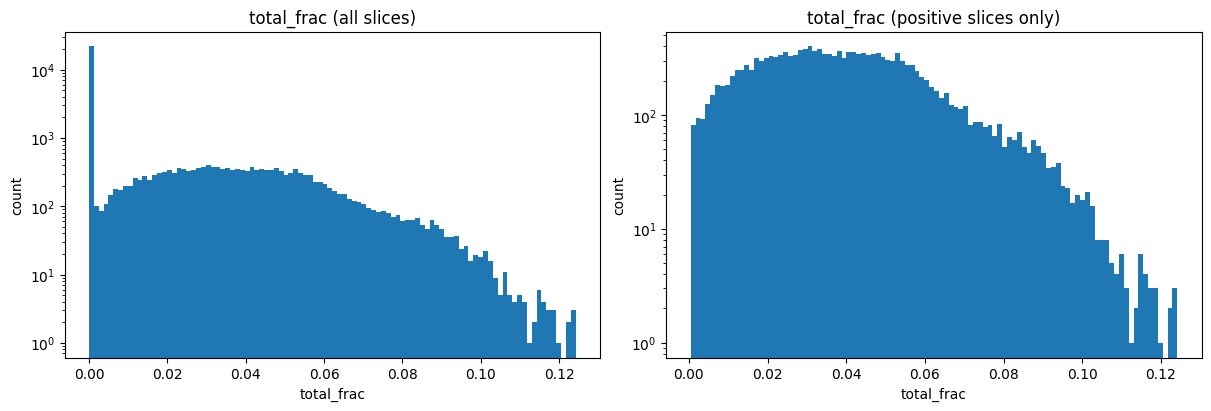

In [12]:
# Plot total_frac distribution (slice-level)
# total_frac = total_area / (H*W) aggregated over 3 classes per slice id.

import numpy as np

OUT_NB_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

all_frac = per_slice['total_frac'].fillna(0.0).to_numpy(dtype=float)
pos_frac = per_slice.loc[per_slice['any_positive'], 'total_frac'].to_numpy(dtype=float)

axes[0].hist(all_frac, bins=100)
axes[0].set_title('total_frac (all slices)')
axes[0].set_xlabel('total_frac')
axes[0].set_ylabel('count')
axes[0].set_yscale('log')

axes[1].hist(pos_frac, bins=100)
axes[1].set_title('total_frac (positive slices only)')
axes[1].set_xlabel('total_frac')
axes[1].set_ylabel('count')
axes[1].set_yscale('log')

SLICE_HIST_PNG = OUT_NB_DIR / 'total_frac_hist_slice_level.png'
fig.savefig(SLICE_HIST_PNG, dpi=200)
print('wrote:', SLICE_HIST_PNG)
plt.show()
